# White-matter bundle profiles on the bundle core

## Scope and claim

This case places **BUAN/AFQ-style weighted microstructural profiles** along the *core path*
of white-matter fiber bundles reconstructed from diffusion MRI. A conventional tract profile
plots a scalar against `0 % -> 100 % of tract length`: the abscissa is an abstract
parameterisation, so a dip in FA is reported at "62 % of the bundle" and its anatomical
location is lost. Placing the same profile on the bundle core keeps the location, and the
path itself - not a surface - is the object of analysis.

This notebook does **not** claim that glyphs outperform linked line charts, and it does not
validate the bundles against an atlas segmentation. The diagnostics below state explicitly
what the spatial embedding does and does not add here.

## Data

Everything is fetched by DIPY's public fetchers:

- **Stanford HARDI** (`fetch_stanford_hardi`): 150 diffusion directions, 2 mm isotropic.
- **Stanford labels** (`fetch_stanford_labels`): a reduced FreeSurfer parcellation in the
  same voxel grid, providing the white-matter mask, the corpus callosum, and cortical /
  subcortical ROIs.

Bundles are defined by **ordered ROI waypoints** with hemisphere and exclusion constraints,
not by a bundle atlas such as HCP842 and not by RecoBundles / TractSeg / pyAFQ bundle
recognition. A streamline is kept only if it visits the waypoints *in the given order*, so
a callosal bundle really runs cortex -> corpus callosum -> contralateral cortex; but the
names below still label **the dominant route between the waypoints**, not an atlas-verified
segmentation, and the scalars come from a single subject's tensor fit.

## What the glyph encodes

Four channels: `FA`, `AD`, `RD` and `dispersion`. `MD`, `curvature` and `support_fraction`
are computed, plotted and exported as raw values, but they are **not** fins - section 6
shows why (`MD = (AD + 2 RD) / 3`; curvature repeats the visible 3D geometry;
`support_fraction` is a tractography count, not a tissue property). Fin length is the
**percentile of the value within this export**, never a physical magnitude.

## 0. Setup

In [1]:
# !pip install dipy nibabel numpy scipy pandas matplotlib plotly scikit-image vtk

import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from nibabel.affines import apply_affine
from scipy.ndimage import (binary_closing, binary_dilation, gaussian_filter,
                           gaussian_filter1d)
from scipy.spatial import cKDTree
from scipy.stats import rankdata

import dipy.reconst.dti as dti
from dipy.core.gradients import gradient_table
from dipy.data import default_sphere, get_fnames
from dipy.direction import peaks_from_model
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti
from dipy.reconst.shm import CsaOdfModel
from dipy.segment.clustering import QuickBundles
from dipy.segment.featurespeed import ResampleFeature
from dipy.segment.metric import AveragePointwiseEuclideanMetric
from dipy.stats.analysis import assignment_map, gaussian_weights
from dipy.tracking import utils
from dipy.tracking.stopping_criterion import ThresholdStoppingCriterion
from dipy.tracking.streamline import (Streamlines, length, orient_by_streamline,
                                      set_number_of_points, values_from_volume)
from dipy.tracking.tracker import deterministic_tracking

try:
    display
except NameError:
    display = print

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

## 1. Configuration

`SEED_DENSITY` is the number of seeds per voxel edge inside the white-matter mask, so a
density of 2 places 8 seeds per voxel. `ROI_DILATION` widens each cortical / subcortical
*waypoint* by that many voxels (2 mm each): deterministic tracking stops at the GFA threshold
before it reaches gray matter, so undilated cortical labels capture almost nothing.
Exclusion ROIs stay undilated, because a dilated exclusion would eat the neighbouring
bundle. `QB_THRESHOLD` is the QuickBundles distance (mm) that identifies the dominant route,
and `MDF_RADIUS_MM` is the distance to that route's centroid within which the other
streamlines are put back (section 4).

Each bundle is an **ordered** chain of waypoints: the streamline must visit ROI 1, then
ROI 2, then ROI 3. The callosal chains are therefore written as
`left cortex -> corpus callosum -> right cortex`, which is the order a callosal streamline
actually traverses. `side` keeps a lateralised bundle in its own hemisphere (allowing
`HEMI_MARGIN_MM` of overshoot around the midline, which is measured from the parcellation
rather than assumed), and `exclude` rejects any streamline entering an undilated ROI - the
cingulum and the thalamo-precentral projections must not run through the corpus callosum.

Seven quantities are measured per node (`CH_ALL`); four of them are glyph channels
(`CH_USE`). The split is justified in section 6, not asserted here.

In [2]:
N_NODES        = 60      # profile nodes along each bundle core
SEED_DENSITY   = 2       # seeds per voxel edge inside the white-matter mask
GFA_THRESHOLD  = 0.25    # tracking stopping criterion
STEP_SIZE      = 0.5     # mm
MAX_ANGLE      = 30      # degrees
ROI_DILATION   = 2       # voxels (2 mm each), waypoints only - exclusions stay undilated
QB_THRESHOLD   = 8.0     # mm, QuickBundles distance used to find the dominant route
MDF_RADIUS_MM  = 12.0    # mm, re-inclusion radius around the dominant centroid
HEMI_MARGIN_MM = 6.0     # mm a lateralised bundle may cross the midline
CORE_SMOOTH    = 1.5     # nodes, core smoothing before the curvature estimate
MIN_LEN_MM     = 40.0
MAX_LEN_MM     = 220.0
MIN_STREAMLINES = 40     # a bundle below this is reported and dropped
FOLD_ARC_SEP   = 20.0    # mm, arc separation that counts as "far along the core"

# Everything measured per node. MD, curvature and support_fraction are computed and
# exported as raw diagnostics but are not glyph channels - see section 6.
CH_ALL = ["FA", "MD", "AD", "RD", "dispersion", "curvature", "support_fraction"]
# What the glyph encodes: three tensor scalars that are not mutually derivable plus one
# geometric descriptor of the bundle. MD = (AD + 2 RD) / 3 would add no direction.
CH_USE = ["FA", "AD", "RD", "dispersion"]

# Ordered waypoint chains. Each entry lists the ROIs in the order a streamline must visit
# them, so the callosal chains read cortex -> corpus callosum -> contralateral cortex.
# `side` restricts a bundle to one hemisphere; `exclude` lists undilated ROIs no point of
# the streamline may enter. Label ids are the Stanford `label_info.txt` reduced
# parcellation (1 = cerebral white matter, 2 = corpus callosum, 3-45 left, 46-88 right).
BUNDLE_SPECS = [
    dict(key="cc_forceps_minor", label="CC forceps minor (frontal)",
         waypoints=[[9, 11], [2], [52, 54]], side=None, exclude=[],
         via="L rostral-middle / superior frontal -> CC -> R rostral-middle / superior frontal"),
    dict(key="cc_body_motor", label="CC body (motor/premotor)",
         waypoints=[[10, 12, 13], [2], [53, 55, 56]], side=None, exclude=[],
         via="L caudal-middle-frontal / precentral / paracentral -> CC -> R homologue"),
    dict(key="cc_parietal", label="CC parietal (mid-posterior)",
         waypoints=[[28, 31, 32], [2], [71, 74, 75]], side=None, exclude=[],
         via="L postcentral / superior-parietal / precuneus -> CC -> R homologue"),
    dict(key="cc_forceps_major", label="CC forceps major (occipital)",
         waypoints=[[33, 34, 35, 36], [2], [76, 77, 78, 79]], side=None, exclude=[],
         via="L cuneus / lateral-occipital / pericalcarine / lingual -> CC -> R homologue"),
    dict(key="cingulum_l", label="Left cingulum",
         waypoints=[[16], [17]], side="L", exclude=[[2]],
         via="L caudal-anterior-cingulate -> L posterior-cingulate, callosum excluded"),
    dict(key="cingulum_r", label="Right cingulum",
         waypoints=[[59], [60]], side="R", exclude=[[2]],
         via="R caudal-anterior-cingulate -> R posterior-cingulate, callosum excluded"),
    dict(key="thalamo_prec_l", label="Left thalamo-precentral",
         waypoints=[[41], [12]], side="L", exclude=[[2]],
         via="L thalamus proper -> L precentral, callosum excluded"),
    dict(key="thalamo_prec_r", label="Right thalamo-precentral",
         waypoints=[[84], [55]], side="R", exclude=[[2]],
         via="R thalamus proper -> R precentral, callosum excluded"),
]

## 2. Diffusion data and tensor scalars

The tensor is fitted inside the parcellated brain mask. `AD` is the principal eigenvalue and
`RD` the mean of the two minor eigenvalues, so `MD`, `AD` and `RD` come from one and the same
eigendecomposition and satisfy `MD = (AD + 2 RD) / 3` exactly. All four are sampled along the
bundles; `MD` is carried through as a raw diagnostic only and is not a glyph channel
(section 6). Reported units are mm^2/s.

In [3]:
hardi_fname, hardi_bval_fname, hardi_bvec_fname = get_fnames(name="stanford_hardi")
label_fname = get_fnames(name="stanford_labels")

data, affine, img = load_nifti(hardi_fname, return_img=True)
labels = load_nifti(label_fname)[0].astype(int)
bvals, bvecs = read_bvals_bvecs(hardi_bval_fname, hardi_bvec_fname)
gtab = gradient_table(bvals, bvecs=bvecs)

brain = labels > 0
white_matter = (labels == 1) | (labels == 2)
print(f"volume       : {data.shape}  voxel {tuple(np.round(img.header.get_zooms()[:3], 2))} mm")
print(f"b-values     : {sorted(set(np.round(bvals, -2).astype(int)))}")
print(f"brain voxels : {brain.sum():,}    white matter: {white_matter.sum():,}")

tenfit = dti.TensorModel(gtab).fit(data, mask=brain)
evals = np.nan_to_num(tenfit.evals)
SCALARS = {
    "FA": np.clip(np.nan_to_num(tenfit.fa), 0, 1),
    "MD": np.nan_to_num(tenfit.md),
    "AD": evals[..., 0],
    "RD": (evals[..., 1] + evals[..., 2]) / 2.0,
}
display(pd.DataFrame([{"scalar": k, "wm mean": v[white_matter].mean(),
                       "wm p5": np.percentile(v[white_matter], 5),
                       "wm p95": np.percentile(v[white_matter], 95)}
                      for k, v in SCALARS.items()]).set_index("scalar").round(6))

volume       : (81, 106, 76, 160)  voxel (np.float32(2.0), np.float32(2.0), np.float32(2.0)) mm
b-values     : [np.int64(0), np.int64(2000)]
brain voxels : 127,466    white matter: 58,788


,wm mean,wm p5,wm p95
scalar,,,
FA,0.434782,0.164851,0.737143
MD,0.000644,0.000538,0.000788
AD,0.000975,0.000723,0.001433
RD,0.000478,0.000284,0.000681


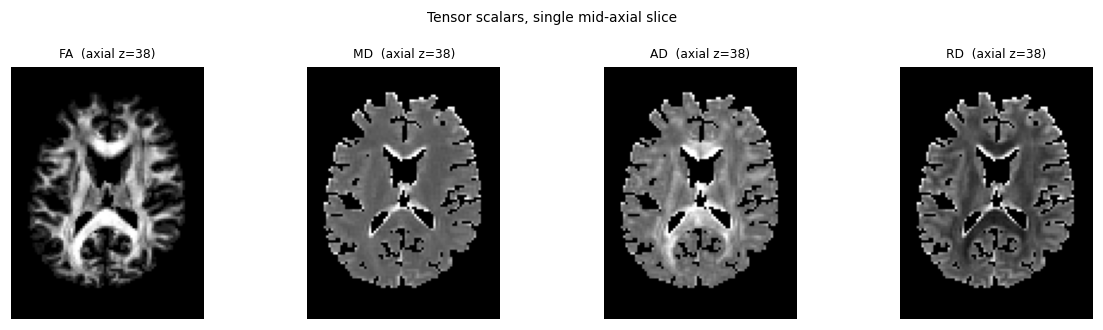

In [4]:
z = data.shape[2] // 2
fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, (name, vol) in zip(axes, SCALARS.items()):
    top = np.percentile(vol[brain], 99)
    ax.imshow(np.rot90(vol[:, :, z]), cmap="gray", vmin=0, vmax=top)
    ax.set_title(f"{name}  (axial z={z})", fontsize=8)
    ax.axis("off")
fig.suptitle("Tensor scalars, single mid-axial slice", fontsize=9)
plt.tight_layout(); plt.show()

## 3. Whole-white-matter deterministic tractogram

Tracking uses constant-solid-angle ODFs and a deterministic tracker: for a profile that is
meant to be read as "the value at this place in this bundle", a reproducible trajectory is
worth more than the wider spatial coverage a probabilistic tracker would give. Seeds cover
the whole white matter so that all bundles come from one tractogram rather than from
per-bundle seeding.

In [5]:
csa_peaks = peaks_from_model(CsaOdfModel(gtab, sh_order_max=6), data, default_sphere,
                             relative_peak_threshold=0.8, min_separation_angle=45,
                             mask=white_matter, npeaks=3, return_sh=True,
                             normalize_peaks=True)

stopping = ThresholdStoppingCriterion(csa_peaks.gfa, GFA_THRESHOLD)
seeds = utils.seeds_from_mask(white_matter, affine, density=SEED_DENSITY)
tractogram = deterministic_tracking(seeds, stopping, affine, sh=csa_peaks.shm_coeff,
                                    sphere=default_sphere, max_angle=MAX_ANGLE,
                                    step_size=STEP_SIZE, min_len=20, max_len=400,
                                    random_seed=42)
STREAMLINES = Streamlines(tractogram)
lengths = np.array([length(s) for s in STREAMLINES])
print(f"seeds       : {len(seeds):,}")
print(f"streamlines : {len(STREAMLINES):,}")
print(f"length (mm) : median {np.median(lengths):.1f}   p95 {np.percentile(lengths, 95):.1f}"
      f"   max {lengths.max():.1f}")

seeds       : 470,304
streamlines : 298,301
length (mm) : median 37.5   p95 102.5   max 199.5


## 4. Bundles from ordered waypoints

`dipy.tracking.utils.target` only answers *"does this streamline touch the ROI?"*, so
chaining it over three ROIs yields the intersection `A and B and C` - a streamline that
touches all three in any arrangement survives. That is not what a bundle definition means.
Here `target` is used only as a cheap prefilter, and the surviving streamlines are then
tested for **order**: the waypoint masks are looked up at the streamline's own points and
the waypoints must match a strictly increasing sequence of point indices (checked in both
directions, since a streamline carries no intrinsic orientation). `A -> B -> C`, not
`A and B and C`.

Three further constraints run with it:

- **length**, to remove short U-fibre fragments and implausibly long loops;
- **hemisphere**, for the lateralised bundles: no point may cross more than
  `HEMI_MARGIN_MM` past the midline, which is measured from the parcellation itself;
- **exclusion**, with undilated masks: a cingulum or thalamo-precentral streamline that
  enters the corpus callosum is callosal contamination and is dropped.

The per-constraint rejection counts are in the table (`-excluded`, `-wrong_side`,
`-out_of_order`), and they say something worth reading rather than assuming. **An ordered
test is vacuous for a two-waypoint chain**: a streamline that touches both ROIs always
admits an increasing match in one of its two directions, which is why `-out_of_order` is
exactly zero for the cingulum and thalamo-precentral bundles - there the callosal exclusion
and the length limits do the work. Ordering only bites on the three-ROI callosal chains, and
there it removes a small number (tens out of thousands): the corpus callosum lies between
the two cortical ROIs anyway, so the intersection was already nearly ordered. That is a
weaker correction than one might expect - it is reported as measured, not as assumed, and
the constraint is kept because "nearly ordered here" is not "ordered by construction".

Finally the route is fixed geometrically. QuickBundles is run on the ordered streamlines and
the largest cluster's centroid defines the dominant route, but the bundle is *not* that
cluster alone: at a 2 mm callosal fan QuickBundles produces dozens of small clusters, and
keeping only the largest one throws away streamlines that follow the same route. Every
ordered streamline whose minimum-average-direct-flip distance to the dominant centroid is
below `MDF_RADIUS_MM` is put back. `kept` is therefore *the streamlines that both satisfy
the ordered anatomy and follow the dominant route*, and `dispersion` in section 5 is the
spread of exactly that set.

The glyph still describes **the dominant route between the waypoints**, not every
anatomically valid streamline connecting them, and not an atlas-verified bundle.

In [6]:
INV_AFFINE = np.linalg.inv(affine)
GRID_MAX = np.array(labels.shape) - 1

# The midline and the sign of the left hemisphere are read off the parcellation instead of
# being assumed: left labels are 3-45, right labels 46-88 in this reduced atlas.
def _label_centroid_x(label_ids):
    voxels = np.argwhere(np.isin(labels, list(label_ids)))
    return float(apply_affine(affine, voxels.mean(0))[0])


MIDLINE_X = float(apply_affine(affine, np.argwhere(brain).mean(0))[0])
X_LEFT, X_RIGHT = _label_centroid_x(range(3, 46)), _label_centroid_x(range(46, 89))
SIDE_SIGN = {"L": -1.0, "R": 1.0} if X_LEFT < X_RIGHT else {"L": 1.0, "R": -1.0}
print(f"midline x = {MIDLINE_X:.1f} mm   left labels at x = {X_LEFT:.1f}, "
      f"right labels at x = {X_RIGHT:.1f}  ->  left is "
      f"{'negative' if SIDE_SIGN['L'] < 0 else 'positive'} x")


def roi_mask(label_ids, dilation=ROI_DILATION):
    mask = np.isin(labels, label_ids)
    if dilation:
        mask = binary_dilation(mask, iterations=dilation)
    return mask & brain


def voxel_index(points):
    """RASMM points -> integer voxel indices, clipped to the volume."""
    return np.clip(np.rint(apply_affine(INV_AFFINE, np.asarray(points))).astype(int),
                   0, GRID_MAX)


def visits_in_order(hits):
    """`hits[k]` marks the points of one streamline that lie in waypoint k. True when the
    waypoints can be matched to a strictly increasing sequence of point indices, i.e. the
    streamline really runs waypoint 0 -> 1 -> 2 rather than merely touching all three."""
    position = -1
    for hit in hits:
        later = np.flatnonzero(hit)
        later = later[later > position]
        if later.size == 0:
            return False
        position = int(later[0])
    return True


def stays_on_side(points, side):
    signed = SIDE_SIGN[side] * (np.asarray(points)[:, 0] - MIDLINE_X)
    return bool(signed.min() > -HEMI_MARGIN_MM)


qb = QuickBundles(threshold=QB_THRESHOLD,
                  metric=AveragePointwiseEuclideanMetric(ResampleFeature(nb_points=N_NODES)))


def mdf_to_centroid(streamlines, centroid):
    """Minimum-average-direct-flip distance of each streamline to a centroid (mm)."""
    resampled = np.stack([np.asarray(s) for s in set_number_of_points(streamlines, N_NODES)])
    reference = np.asarray(centroid)[None]
    direct = np.linalg.norm(resampled - reference, axis=2).mean(1)
    flipped = np.linalg.norm(resampled[:, ::-1] - reference, axis=2).mean(1)
    return np.minimum(direct, flipped)


def extract_bundle(spec):
    stage = {"bundle": spec["label"]}

    masks = [roi_mask(ids) for ids in spec["waypoints"]]
    current = STREAMLINES
    for mask in masks:
        current = Streamlines(utils.target(current, affine, mask))
        if len(current) == 0:
            break
    stage["all waypoints"] = len(current)

    if len(current):
        lens = np.array([length(s) for s in current])
        current = Streamlines([s for s, k in zip(current, (lens > MIN_LEN_MM) & (lens < MAX_LEN_MM)) if k])
    stage["length ok"] = len(current)

    exclusions = [roi_mask(ids, dilation=0) for ids in spec["exclude"]]
    ordered, rejected = [], dict(excluded=0, wrong_side=0, out_of_order=0)
    for s in current:
        voxels = voxel_index(s)
        index = (voxels[:, 0], voxels[:, 1], voxels[:, 2])
        if any(mask[index].any() for mask in exclusions):
            rejected["excluded"] += 1
            continue
        if spec["side"] and not stays_on_side(s, spec["side"]):
            rejected["wrong_side"] += 1
            continue
        hits = [mask[index] for mask in masks]
        if visits_in_order(hits) or visits_in_order([h[::-1] for h in hits]):
            ordered.append(s)
        else:
            rejected["out_of_order"] += 1
    ordered = Streamlines(ordered)
    stage.update({f"-{k}": v for k, v in rejected.items()})
    stage["ordered"] = len(ordered)

    if len(ordered) < MIN_STREAMLINES:
        stage.update({"dominant cluster": 0, "kept": 0, "status": "dropped"})
        return None, stage

    clusters = qb.cluster(ordered)
    main = clusters[int(np.argmax(list(map(len, clusters))))]
    stage["clusters"] = len(clusters)
    stage["dominant cluster"] = len(main.indices)

    # QuickBundles fragments a 2 mm callosal fan into many small clusters, so the largest
    # one alone is a minority of an already anatomically constrained set. The dominant
    # centroid defines the route; every ordered streamline within MDF_RADIUS_MM of it
    # belongs to that route and is put back.
    keep = mdf_to_centroid(ordered, main.centroid) <= MDF_RADIUS_MM
    streamlines = Streamlines([s for s, k in zip(ordered, keep) if k])
    stage["kept"] = len(streamlines)
    stage["status"] = "kept"
    return dict(label=spec["label"], key=spec["key"], via=spec["via"],
                waypoints=spec["waypoints"], side=spec["side"], exclude=spec["exclude"],
                streamlines=streamlines, centroid=main.centroid), stage


BUNDLES, rows = {}, []
for spec in BUNDLE_SPECS:
    bundle, stage = extract_bundle(spec)
    rows.append(stage)
    if bundle is not None:
        BUNDLES[spec["key"]] = bundle

BUNDLE_TABLE = pd.DataFrame(rows).set_index("bundle")
BUNDLE_TABLE["ordered/waypointed"] = (BUNDLE_TABLE["ordered"] / BUNDLE_TABLE["all waypoints"]).round(2)
BUNDLE_TABLE["kept/ordered"] = (BUNDLE_TABLE["kept"] / BUNDLE_TABLE["ordered"]).round(2)
display(BUNDLE_TABLE)

midline x = -0.3 mm   left labels at x = -29.6, right labels at x = 29.3  ->  left is negative x


,all waypoints,length ok,-excluded,-wrong_side,-out_of_order,ordered,clusters,dominant cluster,kept,status,ordered/waypointed,kept/ordered
bundle,,,,,,,,,,,,
CC forceps minor (frontal),11934,11922,0,0,41,11881,124,709,2548,kept,1.00,0.21
CC body (motor/premotor),6339,6333,0,0,43,6290,69,624,3235,kept,0.99,0.51
CC parietal (mid-posterior),7004,6998,0,0,59,6939,102,433,2586,kept,0.99,0.37
CC forceps major (occipital),798,798,0,0,17,781,58,163,410,kept,0.98,0.52
Left cingulum,3025,2600,712,1,1,1886,40,187,610,kept,0.62,0.32
Right cingulum,2529,2058,589,0,0,1469,39,143,473,kept,0.58,0.32
Left thalamo-precentral,1176,1022,56,0,0,966,27,186,388,kept,0.82,0.40
Right thalamo-precentral,572,546,95,0,0,451,17,122,297,kept,0.79,0.66


## 5. Weighted profiles along the bundle core

This is the BUAN / AFQ step. Streamlines are oriented consistently against the QuickBundles
centroid and resampled to `N_NODES` points, and each node of each streamline receives a
weight that is the inverse Mahalanobis distance from the bundle's spatial distribution at
that node (`dipy.stats.analysis.gaussian_weights`). Those weights sum to 1 per node - the
core and every profile below are weighted means and would be meaningless otherwise, so it
is asserted rather than assumed. The **core path** is the weighted mean position per node,
and every tensor profile is the weighted mean of the volume sampled at the streamline
points: peripheral streamlines contribute, but less.

Three quantities describe the reconstruction rather than the tissue, and they are named for
what they are:

- `dispersion` - the **mean distance from the bundle's streamlines to its core** at that
  node, in mm. It is the spread of the whole bundle, *not* the distance of some
  representative path to the core, and it is weighted with the same weights as the tensor
  profiles so that an outlying streamline does not count as much as a central one. The
  unweighted median is kept alongside it as `dispersion_median`, and the 75th percentile
  radius (`radius_p75`) is what the exported envelope tube uses.
- `support_fraction` - the fraction of the bundle's own streamlines reaching each node's
  disk (BUAN's `assignment_map`). This is a **tractography count**, not axon density, not
  fixel-based fiber density and not apparent fiber density: it depends on seeding density
  and tracking parameters. Section 6 shows it is also nearly constant along every bundle.
- `curvature` - curvature of the core, in 1/mm. Differentiating the raw core against the
  *node index* measures bending per node, not per millimetre, and lets resampling jitter
  and the end nodes produce spurious peaks; here the core is lightly smoothed and both
  derivatives are taken against **arc length**.

In [7]:
def core_profile(bundle):
    sl = bundle["streamlines"]
    oriented = Streamlines(set_number_of_points(
        orient_by_streamline(sl, bundle["centroid"]), N_NODES))
    arr = np.stack([np.asarray(s) for s in oriented])            # (n_streamlines, N, 3)

    weights = gaussian_weights(oriented, n_points=N_NODES)       # (n_streamlines, N)
    # The core and every weighted mean below assume the weights of one node sum to 1.
    assert np.allclose(weights.sum(axis=0), 1.0, atol=1e-6), "node weights are not normalised"
    core = np.einsum("ij,ijk->jk", weights, arr)

    profile = {name: (np.asarray(values_from_volume(vol, arr, affine)) * weights).sum(0)
               for name, vol in SCALARS.items()}

    # Spread of the bundle around its own core. Weighted with the same weights as the
    # tensor profiles, so an outlying streamline does not count as much as a central one.
    radial = np.linalg.norm(arr - core[None], axis=2)
    profile["dispersion"] = (radial * weights).sum(0)
    dispersion_median = np.median(radial, axis=0)
    radius_p75 = np.percentile(radial, 75, axis=0)

    # Tracking-derived, not tissue-derived: the fraction of the bundle's own streamlines
    # whose points fall in each node's disk (BUAN's assignment_map on the unresampled
    # streamlines). It reflects seeding and tracking parameters, never axon count.
    disk = np.asarray(assignment_map(sl, [core], N_NODES))
    owner = np.repeat(np.arange(len(sl)), [len(s) for s in sl])
    profile["support_fraction"] = np.array(
        [np.unique(owner[disk == i]).size for i in range(N_NODES)], dtype=float) / len(sl)

    # Curvature of the core, differentiated against arc length (1/mm) on a lightly smoothed
    # path: differentiating the raw core against the node index turns resampling jitter and
    # the end nodes into spurious peaks.
    smooth = gaussian_filter1d(core, CORE_SMOOTH, axis=0, mode="nearest")
    s_arc = np.r_[0.0, np.cumsum(np.linalg.norm(np.diff(smooth, axis=0), axis=1))]
    d1 = np.gradient(smooth, s_arc, axis=0)
    d2 = np.gradient(d1, s_arc, axis=0)
    profile["curvature"] = (np.linalg.norm(np.cross(d1, d2), axis=1)
                            / (np.linalg.norm(d1, axis=1) ** 3 + 1e-12))

    arclen = np.r_[0.0, np.cumsum(np.linalg.norm(np.diff(core, axis=0), axis=1))]
    return dict(core=core, arclen=arclen, radius_p75=radius_p75,
                dispersion_median=dispersion_median, n_streamlines=len(sl), **profile)


for key, bundle in BUNDLES.items():
    bundle.update(core_profile(bundle))

PROFILE_TABLE = pd.DataFrame([
    dict(bundle=b["label"], streamlines=b["n_streamlines"], core_mm=b["arclen"][-1],
         FA=b["FA"].mean(), MD=b["MD"].mean(), AD=b["AD"].mean(), RD=b["RD"].mean(),
         dispersion=b["dispersion"].mean(), disp_median=b["dispersion_median"].mean(),
         curvature=b["curvature"].mean(), support=b["support_fraction"].mean())
    for b in BUNDLES.values()]).set_index("bundle")
display(PROFILE_TABLE.round(5))

,streamlines,core_mm,FA,MD,AD,RD,dispersion,disp_median,curvature,support
bundle,,,,,,,,,,
CC forceps minor (frontal),2548,76.56845,0.58616,0.00062,0.00112,0.00038,4.74533,5.77195,0.05105,0.93418
CC body (motor/premotor),3235,86.73936,0.62361,0.00064,0.00119,0.00037,5.84859,6.79776,0.04905,0.93243
CC parietal (mid-posterior),2586,98.23526,0.64374,0.00063,0.00120,0.00035,5.67991,6.59377,0.04153,0.93989
CC forceps major (occipital),410,126.14969,0.68099,0.00063,0.00126,0.00032,4.50004,5.12027,0.04648,0.94171
Left cingulum,610,58.43619,0.54097,0.00061,0.00104,0.00039,5.92240,6.78104,0.02424,0.89538
Right cingulum,473,68.05233,0.46400,0.00059,0.00092,0.00043,6.24495,6.91321,0.03783,0.90560
Left thalamo-precentral,388,59.18503,0.49831,0.00056,0.00090,0.00039,4.94404,5.36355,0.03580,0.88252
Right thalamo-precentral,297,60.45265,0.56025,0.00057,0.00098,0.00037,4.21744,4.90457,0.02608,0.90522


## 6. Which channels earn a fin

Seven quantities are measured; four are exported as glyph channels. This section is the
justification, and it is descriptive - the correlations are computed over the nodes that are
actually exported.

- **`MD` is dropped.** `MD = (AD + 2 RD) / 3` holds by construction, so with `AD` and `RD`
  already on the glyph, an `MD` fin is a linear combination of two others drawn as if it
  were an independent measurement. `FA`, `AD` and `RD` are also strongly correlated in this
  single-subject fit (see the pairs printed below); that is a property of the tensor model,
  not an error, and the three are kept because none of them is algebraically determined by
  the others - `FA` is not.
- **`support_fraction` is dropped.** Its median over all exported nodes is above 0.99: it
  says almost nothing about the *node* and mostly restates how many streamlines the bundle
  kept. As a fin it would read as a tissue property while encoding a tracking parameter.
- **`curvature` is dropped.** The bending of the tract is already the shape of the path the
  glyph is drawn on; a fin for it re-encodes visible geometry.

All three stay in the export as raw values, with the reason attached, so the frontend can
show them in a tooltip without giving them a fin. The right-hand panel compares the singular
spectrum of all seven measured channels with that of the four exported ones - dropping the
redundant channels costs little of the spanned variance, which is the point.

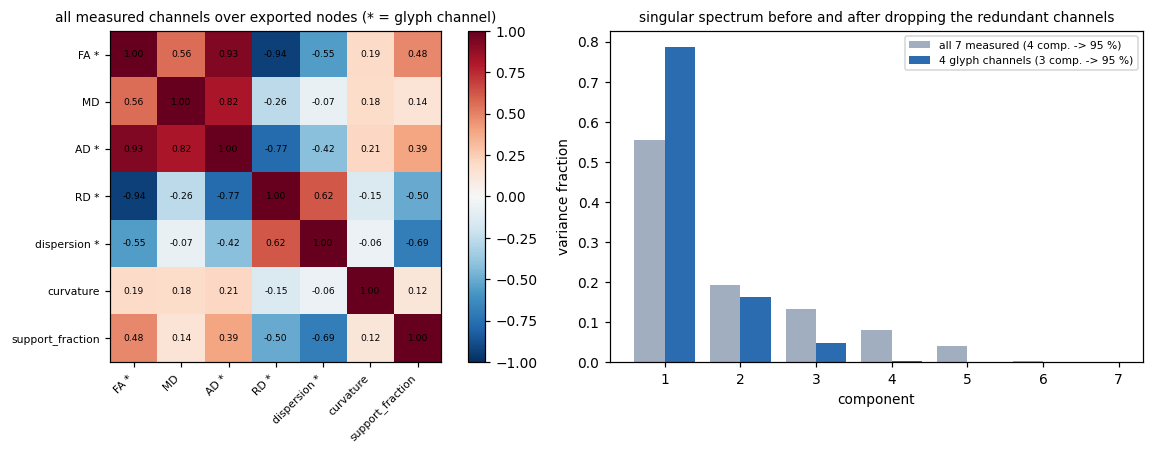

strongest pairs among all measured channels:
  FA               ~ RD                r = -0.94
  FA               ~ AD                r = +0.93
  MD               ~ AD                r = +0.82
  AD               ~ RD                r = -0.77
  dispersion       ~ support_fraction  r = -0.69

strongest pairs among the exported glyph channels:
  FA               ~ RD                r = -0.94
  FA               ~ AD                r = +0.93
  AD               ~ RD                r = -0.77

support_fraction: min 0.475  median 0.993  max 1.000   <- near-constant along every bundle, which is why it is not a fin


In [8]:
RAW_ALL = np.vstack([np.column_stack([b[c] for c in CH_ALL]) for b in BUNDLES.values()])
RAW = RAW_ALL[:, [CH_ALL.index(c) for c in CH_USE]]          # what the glyph exports


def spectrum(matrix):
    z = (matrix - matrix.mean(0)) / (matrix.std(0) + 1e-12)
    ev = np.linalg.svd(z, compute_uv=False) ** 2
    return ev / ev.sum()


Rch = np.corrcoef(RAW_ALL.T)
ev_all, ev_use = spectrum(RAW_ALL), spectrum(RAW)
r95_all = int(np.searchsorted(np.cumsum(ev_all), 0.95) + 1)
r95_use = int(np.searchsorted(np.cumsum(ev_use), 0.95) + 1)
ticks = [f"{c} *" if c in CH_USE else c for c in CH_ALL]

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
im = ax[0].imshow(Rch, cmap="RdBu_r", vmin=-1, vmax=1)
ax[0].set_xticks(range(len(CH_ALL))); ax[0].set_yticks(range(len(CH_ALL)))
ax[0].set_xticklabels(ticks, rotation=45, ha="right", fontsize=7)
ax[0].set_yticklabels(ticks, fontsize=7)
for i in range(len(CH_ALL)):
    for j in range(len(CH_ALL)):
        ax[0].text(j, i, f"{Rch[i, j]:.2f}", ha="center", va="center", fontsize=6)
ax[0].set_title("all measured channels over exported nodes (* = glyph channel)", fontsize=9)
fig.colorbar(im, ax=ax[0], fraction=.046)

width = 0.4
ax[1].bar(np.arange(1, len(ev_all) + 1) - width / 2, ev_all, width,
          color="#a0aec0", label=f"all {len(CH_ALL)} measured ({r95_all} comp. -> 95 %)")
ax[1].bar(np.arange(1, len(ev_use) + 1) + width / 2, ev_use, width,
          color="#2b6cb0", label=f"{len(CH_USE)} glyph channels ({r95_use} comp. -> 95 %)")
ax[1].set_xlabel("component"); ax[1].set_ylabel("variance fraction")
ax[1].set_title("singular spectrum before and after dropping the redundant channels",
                fontsize=9)
ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

print("strongest pairs among all measured channels:")
iu = np.triu_indices(len(CH_ALL), 1)
for k in np.argsort(-np.abs(Rch[iu]))[:5]:
    print(f"  {CH_ALL[iu[0][k]]:16s} ~ {CH_ALL[iu[1][k]]:16s}  r = {Rch[iu][k]:+.2f}")

use_idx = [CH_ALL.index(c) for c in CH_USE]
print("\nstrongest pairs among the exported glyph channels:")
iu_use = np.triu_indices(len(CH_USE), 1)
Ruse = Rch[np.ix_(use_idx, use_idx)]
for k in np.argsort(-np.abs(Ruse[iu_use]))[:3]:
    print(f"  {CH_USE[iu_use[0][k]]:16s} ~ {CH_USE[iu_use[1][k]]:16s}  r = {Ruse[iu_use][k]:+.2f}")

print(f"\nsupport_fraction: min {RAW_ALL[:, CH_ALL.index('support_fraction')].min():.3f}  "
      f"median {np.median(RAW_ALL[:, CH_ALL.index('support_fraction')]):.3f}  "
      f"max {RAW_ALL[:, CH_ALL.index('support_fraction')].max():.3f}"
      "   <- near-constant along every bundle, which is why it is not a fin")

## 7. Does a bundle core fold?

Folding means the path returns close to its own past: two nodes near each other in space but
far apart along the core. Where that happens, arc length alone cannot reproduce the spatial
layout. The same test as in the aneurysm case is applied here, plus a second test that the
one-dimensional tract profile cannot address at all: how close *different* bundles come to
each other.

In [9]:
keys = list(BUNDLES)
rows = []
for key in keys:
    b = BUNDLES[key]
    tree = cKDTree(b["core"])
    for R in (5.0, 10.0, 15.0):
        pairs = tree.query_pairs(R, output_type="ndarray")
        far = int((np.abs(b["arclen"][pairs[:, 0]] - b["arclen"][pairs[:, 1]])
                   > FOLD_ARC_SEP).sum()) if len(pairs) else 0
        rows.append(dict(bundle=b["label"], radius_mm=R, pairs=len(pairs), folding_pairs=far))
SELF_FOLD = pd.DataFrame(rows).pivot(index="bundle", columns="radius_mm",
                                     values="folding_pairs")
print("self-contacts with arc separation > "
      f"{FOLD_ARC_SEP:.0f} mm (columns = search radius, mm):")
display(SELF_FOLD)

cross = np.zeros((len(keys), len(keys)), dtype=int)
for i, a in enumerate(keys):
    tree = cKDTree(BUNDLES[a]["core"])
    for j, b in enumerate(keys):
        if i >= j:
            continue
        n = sum(len(x) for x in tree.query_ball_point(BUNDLES[b]["core"], 12.0))
        cross[i, j] = cross[j, i] = n
CROSS = pd.DataFrame(cross, index=[BUNDLES[k]["label"] for k in keys],
                     columns=[BUNDLES[k]["label"] for k in keys])
print("\nnode pairs within 12 mm between different bundle cores:")
display(CROSS)

self-contacts with arc separation > 20 mm (columns = search radius, mm):


radius_mm,5.0,10.0,15.0
bundle,,,
CC body (motor/premotor),0,0,0
CC forceps major (occipital),0,0,0
CC forceps minor (frontal),0,0,0
CC parietal (mid-posterior),0,0,0
Left cingulum,0,0,0
Left thalamo-precentral,0,0,0
Right cingulum,0,0,0
Right thalamo-precentral,0,0,0



node pairs within 12 mm between different bundle cores:


,CC forceps minor (frontal),CC body (motor/premotor),CC parietal (mid-posterior),CC forceps major (occipital),Left cingulum,Right cingulum,Left thalamo-precentral,Right thalamo-precentral
CC forceps minor (frontal),0,0,0,0,0,0,0,0
CC body (motor/premotor),0,0,0,0,288,243,196,154
CC parietal (mid-posterior),0,0,0,54,114,50,0,0
CC forceps major (occipital),0,0,54,0,0,0,0,0
Left cingulum,0,288,114,0,0,0,0,0
Right cingulum,0,243,50,0,0,0,0,6
Left thalamo-precentral,0,196,0,0,0,0,0,0
Right thalamo-precentral,0,154,0,0,0,6,0,0


### Reading the two tables

`folding_pairs` is **zero for every bundle at every radius**: none of these cores doubles
back on itself. Within a single bundle, position along the core is therefore a monotone
function of arc length, and for that bundle alone the glyph carries no adjacency information
that `0 % -> 100 %` lacks. This is a negative result and it is stated as one: this case does
not demonstrate self-folding relationships that a line profile cannot express.

What the embedding does carry is between bundles and between the profile and anatomy: the
cores run near each other in specific places (second table), and a change reported at "62 %
of the CC body" lands at an identifiable point of the callosal arch. That - putting
along-tract variation back at its anatomical location - is the claim this case supports.
The next section shows the baseline it is measured against.

## 8. Tract profiles - the quantitative baseline

The standard presentation: each scalar against percentage of bundle length, one line per
bundle. All seven measured quantities are plotted, with the four exported as glyph channels
marked `*`. Everything the glyph shows is in these panels; the abscissa is what differs.

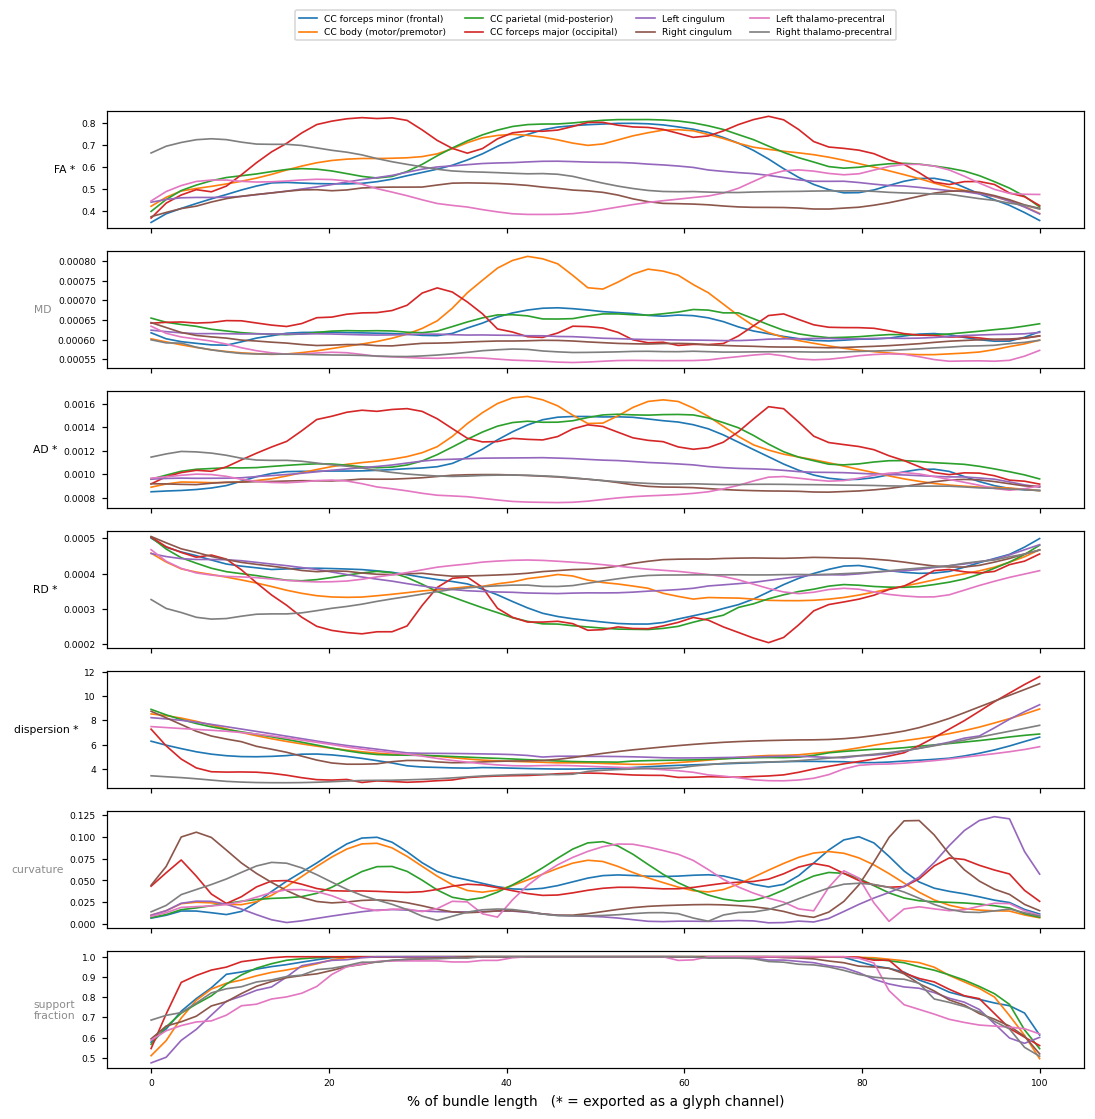

In [10]:
pct = np.linspace(0, 100, N_NODES)
colors = plt.cm.tab10(np.linspace(0, 1, 10))
fig, axes = plt.subplots(len(CH_ALL), 1, figsize=(10, 1.45 * len(CH_ALL)), sharex=True)
for ax_, ch in zip(axes, CH_ALL):
    for i, b in enumerate(BUNDLES.values()):
        ax_.plot(pct, b[ch], lw=1.1, color=colors[i % 10], label=b["label"])
    glyph = " *" if ch in CH_USE else ""
    ax_.set_ylabel(ch.replace("_", "\n") + glyph, rotation=0, ha="right", va="center",
                   fontsize=7, color="black" if glyph else "#8a8a8a")
    ax_.tick_params(labelsize=6)
axes[-1].set_xlabel("% of bundle length   (* = exported as a glyph channel)")
axes[0].legend(fontsize=6, ncol=4, loc="upper center", bbox_to_anchor=(.5, 1.9))
plt.tight_layout(); plt.show()

## 9. Glyph values

One polygon is placed at each core node, one fin per exported channel. The four channels are
non-negative, and they are rank-normalised **jointly over every node of every bundle**, so a
fin length is the value's **percentile within this export** - 480 nodes from 8 bundles of
one subject.

That is what the legend has to say. A long `FA` fin means *high FA relative to the other
nodes exported here*; it is not the raw FA, not a z-score against a healthy population, and
not a clinical judgement. The raw measurement travels with every node in
`attributes.raw_values`, and the per-channel percentile table is written to
`meta.quantiles`, so a viewer can map a fin back to a number.

The normalisation asserts that every exported value is finite and non-negative instead of
silently mapping invalid entries to a zero-length fin: a channel that is not measurable at a
node is a bug to be seen, not a short fin to be read.

glyph vertices (4): ['FA', 'AD', 'RD', 'dispersion']
nodes exported : 480 = 8 bundles x 60 nodes
fin length     : percentile of the raw value among those 480 nodes, not a physical magnitude


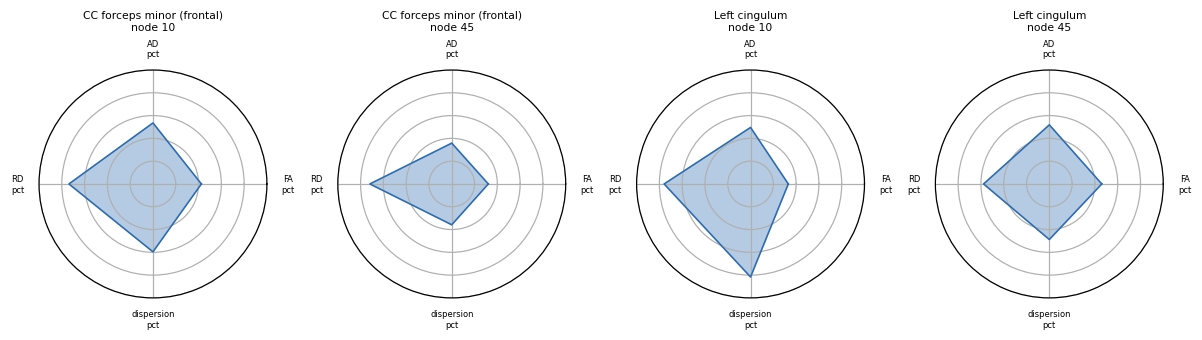

In [11]:
def rank_percentile(raw, names):
    """Percentile of each raw value within this export, one ranking per channel."""
    assert np.all(np.isfinite(raw)), "non-finite value in an exported channel"
    assert np.all(raw >= 0), "negative value in an exported channel"
    for name, n_zero in zip(names, (raw == 0).sum(0)):
        if n_zero:
            print(f"note: {name} is exactly zero at {n_zero} nodes - they take the lowest ranks")
    return np.column_stack([rankdata(raw[:, j]) / raw.shape[0] for j in range(raw.shape[1])])


NORM = rank_percentile(RAW, CH_USE)
print(f"glyph vertices ({len(CH_USE)}): {CH_USE}")
print(f"nodes exported : {NORM.shape[0]} = {len(BUNDLES)} bundles x {N_NODES} nodes")
print("fin length     : percentile of the raw value among those "
      f"{NORM.shape[0]} nodes, not a physical magnitude")

show = ["cc_forceps_minor", "cingulum_l"]
fig, axes = plt.subplots(1, 4, figsize=(11, 3), subplot_kw=dict(projection="polar"))
ang = np.linspace(0, 2 * np.pi, len(CH_USE), endpoint=False)
offsets = {k: i * N_NODES for i, k in enumerate(BUNDLES)}
for ax_, (key, node) in zip(axes, [(k, n) for k in show for n in (10, 45)]):
    v = NORM[offsets[key] + node]
    ax_.fill(np.r_[ang, ang[0]], np.r_[v, v[0]], color="#2b6cb0", alpha=.35)
    ax_.plot(np.r_[ang, ang[0]], np.r_[v, v[0]], color="#2b6cb0", lw=1)
    ax_.set_xticks(ang); ax_.set_xticklabels([f"{c}\npct" for c in CH_USE], fontsize=5.5)
    ax_.set_yticklabels([]); ax_.set_ylim(0, 1)
    ax_.set_title(f"{BUNDLES[key]['label']}\nnode {node}", fontsize=7)
plt.tight_layout(); plt.show()

## 10. Anatomical context in 3D

The core paths are drawn inside the brain surfaces, with a thinned sample of each bundle's
streamlines. This is the arrangement the frontend reproduces: an opaque core carrying the
glyph, a transparent envelope for the bundle's spatial extent, and brain surfaces for
orientation.

Two context surfaces are built. The **brain-mask hull** is only an envelope - it is smooth
and carries no recognisable anatomy. The **white-matter boundary** (labels 1 and 2) is the
folded surface the bundles actually terminate on, so it shows gyral / sulcal structure, the
ventricles and the callosal arch, and it is kept at a finer decimation target for that
reason.

In [12]:
import plotly.graph_objects as go
from nibabel.affines import apply_affine
from skimage.measure import marching_cubes


def brain_surface(mask, affine, sigma=1.2, step=2, target_faces=6000):
    smooth = gaussian_filter(binary_closing(mask, iterations=2).astype(float), sigma)
    verts, faces, _, _ = marching_cubes(smooth, level=0.5, step_size=step)
    verts = apply_affine(affine, verts)
    if len(faces) > target_faces:
        import vtk
        from vtk.util.numpy_support import numpy_to_vtk, numpy_to_vtkIdTypeArray, vtk_to_numpy
        points = vtk.vtkPoints()
        points.SetData(numpy_to_vtk(np.ascontiguousarray(verts, dtype=np.float64), deep=1))
        cells = vtk.vtkCellArray()
        flat = np.hstack([np.full((len(faces), 1), 3, dtype=np.int64),
                          np.asarray(faces, dtype=np.int64)]).ravel()
        cells.SetCells(len(faces), numpy_to_vtkIdTypeArray(flat, deep=1))
        polydata = vtk.vtkPolyData(); polydata.SetPoints(points); polydata.SetPolys(cells)
        decimate = vtk.vtkQuadricDecimation()
        decimate.SetInputData(polydata)
        decimate.SetTargetReduction(1.0 - target_faces / len(faces))
        decimate.Update()
        out = decimate.GetOutput()
        verts = vtk_to_numpy(out.GetPoints().GetData())
        faces = vtk_to_numpy(out.GetPolys().GetData()).reshape(-1, 4)[:, 1:]
    return np.asarray(verts), np.asarray(faces)


BRAIN_VERTS, BRAIN_FACES = brain_surface(brain, affine)
# Finer sampling and a higher face budget: this surface has to keep its folds.
WM_VERTS, WM_FACES = brain_surface(white_matter, affine, sigma=0.7, step=1,
                                   target_faces=26000)
print(f"brain-mask hull       : {len(BRAIN_VERTS):,} vertices, {len(BRAIN_FACES):,} faces")
print(f"white-matter boundary : {len(WM_VERTS):,} vertices, {len(WM_FACES):,} faces")

palette = ["#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4",
           "#46f0f0", "#f032e6", "#bcf60c"]
fig = go.Figure()
fig.add_trace(go.Mesh3d(x=BRAIN_VERTS[:, 0], y=BRAIN_VERTS[:, 1], z=BRAIN_VERTS[:, 2],
                        i=BRAIN_FACES[:, 0], j=BRAIN_FACES[:, 1], k=BRAIN_FACES[:, 2],
                        color="lightgray", opacity=.07, name="brain mask", showscale=False))
fig.add_trace(go.Mesh3d(x=WM_VERTS[:, 0], y=WM_VERTS[:, 1], z=WM_VERTS[:, 2],
                        i=WM_FACES[:, 0], j=WM_FACES[:, 1], k=WM_FACES[:, 2],
                        color="#b9c9d6", opacity=.22, name="white matter", showscale=False))
for i, b in enumerate(BUNDLES.values()):
    sample = b["streamlines"][::max(1, len(b["streamlines"]) // 40)]
    xs, ys, zs = [], [], []
    for s in sample:
        xs += list(s[:, 0]) + [None]; ys += list(s[:, 1]) + [None]; zs += list(s[:, 2]) + [None]
    fig.add_trace(go.Scatter3d(x=xs, y=ys, z=zs, mode="lines", showlegend=False,
                               line=dict(color=palette[i % 8], width=1), opacity=.25,
                               hoverinfo="skip"))
    fig.add_trace(go.Scatter3d(x=b["core"][:, 0], y=b["core"][:, 1], z=b["core"][:, 2],
                               mode="lines", name=b["label"],
                               line=dict(color=palette[i % 8], width=7)))
fig.update_layout(width=900, height=650, margin=dict(l=0, r=0, t=30, b=0),
                  scene=dict(aspectmode="data"),
                  title="Bundle cores and thinned streamlines inside the brain mask")
fig.show()

brain-mask hull       : 3,006 vertices, 6,000 faces
white-matter boundary : 12,942 vertices, 25,999 faces


## 11. Export for the frontend

Two files are written to `Frontend/public`:

- `wm_tract_glyph.json` - one object per bundle, one point per core node. `values` holds the
  four glyph channels as percentiles within this export; `attributes.raw_values` holds all
  seven measured quantities in their own units. `meta.channelInfo` gives the legend text for
  each fin (`FA percentile`, `AD percentile`, `RD percentile`,
  `Bundle dispersion percentile`) together with the raw unit behind it, and
  `meta.diagnosticChannels` records why `MD`, `curvature` and `support_fraction` are
  exported without a fin. Each object also carries the waypoint chain it was defined by.
- `wm_tract_geometry.json` - a transparent tube per bundle whose radius is the 75th
  percentile distance from the core to its streamlines at that node, plus both context
  surfaces (brain-mask hull and white-matter boundary).

Coordinates in both files are RASMM scanner-anatomical millimetres, so glyphs and geometry
share one frame.

In [13]:
# Circular sweep around the core with a per-node radius, using a parallel-transport
# frame so the cross-sections do not twist along strongly curved bundles.
def tube_mesh(core, radii, n_seg=12):
    core = np.asarray(core, dtype=float)
    tangent = np.gradient(core, axis=0)
    tangent /= np.linalg.norm(tangent, axis=1, keepdims=True) + 1e-12

    reference = np.array([0.0, 0.0, 1.0])
    if abs(np.dot(reference, tangent[0])) > 0.9:
        reference = np.array([1.0, 0.0, 0.0])
    normal = np.cross(tangent[0], reference)
    normal /= np.linalg.norm(normal) + 1e-12

    verts = []
    for i, (point, radius) in enumerate(zip(core, radii)):
        if i > 0:
            normal = normal - tangent[i] * np.dot(normal, tangent[i])
            norm = np.linalg.norm(normal)
            normal = normal / norm if norm > 1e-9 else np.cross(tangent[i], reference)
            normal /= np.linalg.norm(normal) + 1e-12
        binormal = np.cross(tangent[i], normal)
        for j in range(n_seg):
            a = 2 * np.pi * j / n_seg
            verts.append(point + radius * (np.cos(a) * normal + np.sin(a) * binormal))

    faces = []
    for i in range(len(core) - 1):
        for j in range(n_seg):
            a = i * n_seg + j
            b = i * n_seg + (j + 1) % n_seg
            faces += [[a, b, a + n_seg], [b, b + n_seg, a + n_seg]]
    return np.asarray(verts), faces


def _round(values, digits=4):
    return [round(float(v), digits) for v in values]


# What a fin means, for the frontend legend: the fin is a percentile, the tooltip value is
# the measurement. Channels that are not fins are still exported as raw values, with the
# reason they are not fins.
CHANNEL_INFO = {
    "FA": dict(label="FA percentile", raw="fractional anisotropy (dimensionless, 0-1)",
               description="Gaussian-weighted mean fractional anisotropy of the bundle at "
                           "this node."),
    "AD": dict(label="AD percentile", raw="axial diffusivity (mm^2/s)",
               description="Weighted mean principal eigenvalue - diffusion along the fibre "
                           "direction."),
    "RD": dict(label="RD percentile", raw="radial diffusivity (mm^2/s)",
               description="Weighted mean of the two minor eigenvalues - diffusion across "
                           "the fibre direction."),
    "dispersion": dict(label="Bundle dispersion percentile",
                       raw="weighted mean distance to the bundle core (mm)",
                       description="How far the bundle's streamlines sit from the core at "
                                   "this node - the spread of the whole bundle, not the "
                                   "distance of one path to the core."),
}
DIAGNOSTIC_INFO = {
    "MD": "Mean diffusivity (mm^2/s). Raw value only: MD = (AD + 2 RD) / 3, so it adds no "
          "direction the exported channels do not already carry.",
    "curvature": "Curvature of the smoothed core differentiated against arc length (1/mm). "
                 "Raw value only: the bending of the tract is already visible in the 3D path.",
    "support_fraction": "Fraction of the bundle's own streamlines reaching this node's disk. "
                        "Raw value only: it is tractography-derived (seeding and tracking "
                        "parameters), not an axon or fibre density, and it is near-constant "
                        "along each bundle.",
}

public = Path("Frontend/public")
if not public.exists():
    public = Path("../Frontend/public")
public.mkdir(parents=True, exist_ok=True)
glyph_path = public / "wm_tract_glyph.json"
geometry_path = public / "wm_tract_geometry.json"

objects, bundle_meshes, offset = [], [], 0
for object_id, (key, b) in enumerate(BUNDLES.items()):
    normalized = NORM[offset:offset + N_NODES]
    offset += N_NODES
    points = []
    for i in range(N_NODES):
        points.append({
            "x": round(float(b["core"][i, 0]), 4),
            "y": round(float(b["core"][i, 1]), 4),
            "z": round(float(b["core"][i, 2]), 4),
            "values": _round(normalized[i]),
            "attributes": {
                "node": i,
                "arclen": round(float(b["arclen"][i]), 4),
                "percent": round(100.0 * i / (N_NODES - 1), 2),
                "coreRadiusP75": round(float(b["radius_p75"][i]), 4),
                "dispersionMedian": round(float(b["dispersion_median"][i]), 4),
                "sampling": "gaussian-weighted (inverse Mahalanobis) bundle profile",
                "raw_values": {c: round(float(b[c][i]), 8) for c in CH_ALL},
            },
        })
    objects.append({"objectId": object_id, "label": b["label"], "key": key,
                    "route": b["via"], "nStreamlines": int(b["n_streamlines"]),
                    "points": points})

    verts, faces = tube_mesh(b["core"], b["radius_p75"])
    bundle_meshes.append({
        "objectId": object_id, "key": key, "label": b["label"],
        "nStreamlines": int(b["n_streamlines"]),
        "mesh": {"vertices": [_round(v) for v in verts], "faces": faces},
    })

glyph_payload = {
    "meta": {
        "caseType": "wm-tract-bundle-profiles",
        "title": "White-matter bundle profiles on the bundle core",
        "description": "One object per fiber bundle; each point is a node of the "
                       "gaussian-weighted bundle core carrying a BUAN/AFQ-style profile.",
        "interpretation": "FA, AD and RD are weighted means of a single-subject tensor fit "
                          "sampled at the bundle's streamline points; dispersion is the "
                          "weighted mean distance from those streamlines to the core and "
                          "describes the reconstructed bundle, not the tissue.",
        "glyphValues": "Every fin length is the percentile of the raw value among all "
                       f"{len(objects) * N_NODES} exported nodes of these {len(objects)} "
                       "bundles. It is a within-sample rank, not a physical magnitude and "
                       "not a deviation from a population norm; the measurement itself is "
                       "in attributes.raw_values.",
        "limitation": "Bundles are defined by ordered ROI waypoints with hemisphere and "
                      "exclusion constraints, not by an atlas such as HCP842 or by "
                      "RecoBundles, so the labels name the dominant route between the "
                      "waypoints rather than an atlas-verified bundle. Scalars come from "
                      "one subject. No bundle core folds back on itself, so within a single "
                      "bundle the spatial embedding adds no adjacency beyond arc length.",
        "unit": "coordinates/arclen/dispersion in mm (RASMM); AD/RD/MD in mm^2/s; FA "
                "dimensionless; curvature in 1/mm; glyph values are percentiles in (0,1]",
        "source": {
            "dwi": "Stanford HARDI (dipy fetch_stanford_hardi)",
            "labels": "Stanford aparc-reduced (dipy fetch_stanford_labels)",
            "tractography": f"CSA ODF, deterministic, GFA>{GFA_THRESHOLD}, "
                            f"step {STEP_SIZE} mm, max angle {MAX_ANGLE} deg, "
                            f"seed density {SEED_DENSITY}",
            "bundles": f"ordered waypoint chains (ROI dilation {ROI_DILATION} voxels), "
                       f"hemisphere margin {HEMI_MARGIN_MM} mm, undilated exclusion ROIs, "
                       f"QuickBundles {QB_THRESHOLD} mm for the dominant route and "
                       f"MDF re-inclusion within {MDF_RADIUS_MM} mm of its centroid",
            "profiles": "dipy.stats.analysis gaussian_weights + assignment_map",
        },
        "nObjects": len(objects),
        "nPointsPerObject": [N_NODES] * len(objects),
        "nNodes": N_NODES,
        "nStreamlinesPerObject": [int(b["n_streamlines"]) for b in BUNDLES.values()],
        "nWholeBrainStreamlines": int(len(STREAMLINES)),
        "roiDilationVoxels": ROI_DILATION,
        "qbThresholdMm": QB_THRESHOLD,
        "mdfRadiusMm": MDF_RADIUS_MM,
        "globalChannelNormalization": True,
        "channelInfo": CHANNEL_INFO,
        "diagnosticChannels": DIAGNOSTIC_INFO,
        "coordinates": "RASMM scanner-anatomical millimeters",
        "quantiles": {c: _round(np.percentile(RAW[:, i], np.linspace(0, 100, 101)), 8)
                      for i, c in enumerate(CH_USE)},
    },
    "channels": CH_USE,
    "objects": objects,
}

geometry_payload = {
    "meta": {
        "caseType": "wm-tract-bundles",
        "title": "Bundle envelopes and brain-mask context",
        "description": "Transparent per-bundle tubes plus the brain-mask isosurface; the "
                       "glyph cores themselves are stored in wm_tract_glyph.json.",
        "unit": "millimeters (RASMM)",
        "meshKind": "surface-triangles",
        "tubeRadius": "75th percentile distance from the core to its streamlines, per node",
    },
    "bundles": bundle_meshes,
    "context": {
        "description": "Isosurface of the parcellated brain mask, gaussian-smoothed and "
                       "quadric-decimated. An envelope only - it carries no internal "
                       "structure.",
        "mesh": {"vertices": [_round(v) for v in BRAIN_VERTS],
                 "faces": [[int(v) for v in f] for f in BRAIN_FACES]},
        "whiteMatter": {
            "description": "Isosurface of the white-matter mask (labels 1 and 2), kept at a "
                           "finer decimation target so gyral folding, the ventricles and the "
                           "callosal arch stay legible.",
            "mesh": {"vertices": [_round(v) for v in WM_VERTS],
                     "faces": [[int(v) for v in f] for f in WM_FACES]},
        },
    },
}

with open(glyph_path, "w") as f:
    json.dump(glyph_payload, f, indent=2)
with open(geometry_path, "w") as f:
    json.dump(geometry_payload, f, separators=(",", ":"))

print(f"saved {glyph_path}: {len(objects)} bundles, "
      f"{sum(len(o['points']) for o in objects)} glyph nodes, "
      f"channels {CH_USE} ({glyph_path.stat().st_size / 1e6:.2f} MB)")
print(f"saved {geometry_path}: {len(bundle_meshes)} tubes + brain hull "
      f"({len(BRAIN_FACES):,} faces) + white matter ({len(WM_FACES):,} faces) "
      f"({geometry_path.stat().st_size / 1e6:.2f} MB)")

saved ../Frontend/public/wm_tract_glyph.json: 8 bundles, 480 glyph nodes, channels ['FA', 'AD', 'RD', 'dispersion'] (0.39 MB)
saved ../Frontend/public/wm_tract_geometry.json: 8 tubes + brain hull (6,000 faces) + white matter (25,999 faces) (1.26 MB)
